# STAT 5010 Final Project
# NBA Analytics using R

## Done by:
- **Pranav Unnikrishnan** [111370740]
- **Rishekesan Senthil Kumar Vanathi** [111350847]


**Project Link:** [NBA Analytics using R](https://github.com/prnv19/NBA-Analytics-Using-R)

**Dataset:** [Link](https://github.com/prnv19/NBA-Analytics-Using-R/blob/main/Data/Processed/nba_normal_scorers_filtered.csv)


In this project, player performance data from the NBA seasons 2020 through 2025 was collected using web scraping techniques from Basketball-Reference (Stats) and Hoopshype (Salary) websites. Two main datasets were created: one containing normal scorers and another identifying high-scoring outliers based on points-per-game thresholds using the interquartile range (IQR) method. Player salary data was separately scraped and merged with the performance datasets. Additional data cleaning steps included handling players listed under multiple teams, ensuring consistency in player names, and isolating the 2025 season data for specialized analysis. The final datasets include comprehensive features such as player age, team, position, game statistics (e.g., points, assists, rebounds), and corresponding salary information, enabling a robust foundation for statistical modeling and insights.

Techniques used in this project include:
- Hypothesis testing
- Diagnostics of the model
- Multiple linear regression
- ANOVA
- Generalized Additive model (GAM)

The objective of this project is to first perform some hypothesis tests to check the data and then build a model to predict the salary of the players based on their performance. Additionally, the project aims to predict the points per game of the players using only certain features to find out the most important features that affect the points per game of the players. This will be done using, MLR, GAM and poisson regression. The diagnostics will also be done for each model. We will also use the Chi Square test to check the fit of the model for some models in order to understand whether a reduced model would be sufficient or not.

The models will also be evaluated using the MAE and $R^2$ metrics. This will enable us to understand how each model performs and which model is the best fit for the data. The final goal is to build a model that can accurately predict the salary of the players based on their performance and also find out the most important features that affect the points per game of the players.

## Hypothesis Testing

In [1]:
rm(list=ls())

#### Load Dataset

In [2]:
set.seed(123)

norm_data = read.csv("Data/Processed/nba_normal_scorers_filtered.csv")

# Comment the line above and uncomment the line below if you are downloading the data using the link
# Make sure the dataset is in the same directory as this notebook

# norm_data = read.csv("nba_normal_scorers_filtered.csv")

norm_data = subset(norm_data, select = -c(Player, Team, Pos, Awards, AllStarSelection, Rk))

norm_data = na.omit(norm_data)

n = floor(0.8 * nrow(norm_data))
index = sample(seq_len(nrow(norm_data)), size = n)

norm.train = norm_data[index, ]
norm.test = norm_data[-index, ]

head(norm.train)
summary(norm.train)

# Our eval function
mae = function(actual, predicted) {
    mean(abs(actual - predicted))
}

,Age,G,GS,MP,FG,FGA,FG.,X3P,X3PA,X3P.,⋯,DRB,TRB,AST,STL,BLK,TOV,PF,PTS,Year,Salary
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<dbl>
511,32,55,7,17.3,2.2,5.2,0.433,0.7,1.5,0.439,⋯,1.3,1.6,2.4,0.6,0.2,1.2,1.0,6.7,2021,4110433
568,27,29,4,10.9,1.9,3.9,0.496,0.1,0.5,0.200,⋯,1.7,2.7,0.1,0.1,0.5,0.5,1.8,4.6,2021,2294633
209,24,37,12,24.5,1.8,4.4,0.414,0.6,1.9,0.324,⋯,1.8,2.3,2.1,1.1,0.1,0.8,1.6,4.6,2020,4906243
645,20,15,1,5.6,0.7,1.8,0.407,0.3,0.7,0.400,⋯,0.7,1.1,0.3,0.2,0.3,0.3,0.7,1.9,2021,1849950
229,25,42,5,13.5,1.3,3.2,0.406,0.9,2.6,0.351,⋯,1.7,2.6,0.4,0.1,0.5,0.2,1.1,3.7,2020,881609
1203,32,68,40,24.4,3.9,9.4,0.411,1.4,4.2,0.333,⋯,1.8,2.1,3.4,0.7,0.1,1.7,1.7,10.2,2023,12147949


      Age              G               GS              MP       
 Min.   :19.00   Min.   : 1.00   Min.   : 0.00   Min.   : 2.00  
 1st Qu.:22.00   1st Qu.:24.00   1st Qu.: 0.00   1st Qu.:12.03  
 Median :24.00   Median :48.00   Median : 5.00   Median :17.95  
 Mean   :25.46   Mean   :44.33   Mean   :18.51   Mean   :18.79  
 3rd Qu.:28.00   3rd Qu.:65.00   3rd Qu.:31.00   3rd Qu.:25.80  
 Max.   :43.00   Max.   :84.00   Max.   :83.00   Max.   :43.50  
       FG             FGA              FG.              X3P        
 Min.   :0.000   Min.   : 0.500   Min.   :0.0000   Min.   :0.0000  
 1st Qu.:1.400   1st Qu.: 3.400   1st Qu.:0.3990   1st Qu.:0.3000  
 Median :2.500   Median : 5.600   Median :0.4400   Median :0.7000  
 Mean   :2.947   Mean   : 6.499   Mean   :0.4456   Mean   :0.9073  
 3rd Qu.:4.000   3rd Qu.: 8.600   3rd Qu.:0.4920   3rd Qu.:1.3000  
 Max.   :8.800   Max.   :19.400   Max.   :0.7470   Max.   :4.0000  
      X3PA            X3P.             X2P             X2PA       
 M

## Multiple Linear Regression

#### 1. Prediction of Salary


Call:
lm(formula = sqrt(Salary) ~ Age + MP + FG + X3P + AST + DRB + 
    BLK, data = norm.train)

Residuals:
    Min      1Q  Median      3Q     Max 
-4299.8  -627.2    17.5   640.2  3526.4 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)    
(Intercept) -2247.037    182.799 -12.292  < 2e-16 ***
Age           113.744      6.915  16.449  < 2e-16 ***
MP              2.851      9.196   0.310   0.7566    
FG            221.071     36.198   6.107 1.38e-09 ***
X3P           150.268     62.027   2.423   0.0156 *  
AST           171.975     26.540   6.480 1.35e-10 ***
DRB           142.061     35.439   4.009 6.50e-05 ***
BLK           226.540     98.519   2.299   0.0217 *  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 990.4 on 1162 degrees of freedom
Multiple R-squared:  0.5706,	Adjusted R-squared:  0.568 
F-statistic: 220.6 on 7 and 1162 DF,  p-value: < 2.2e-16


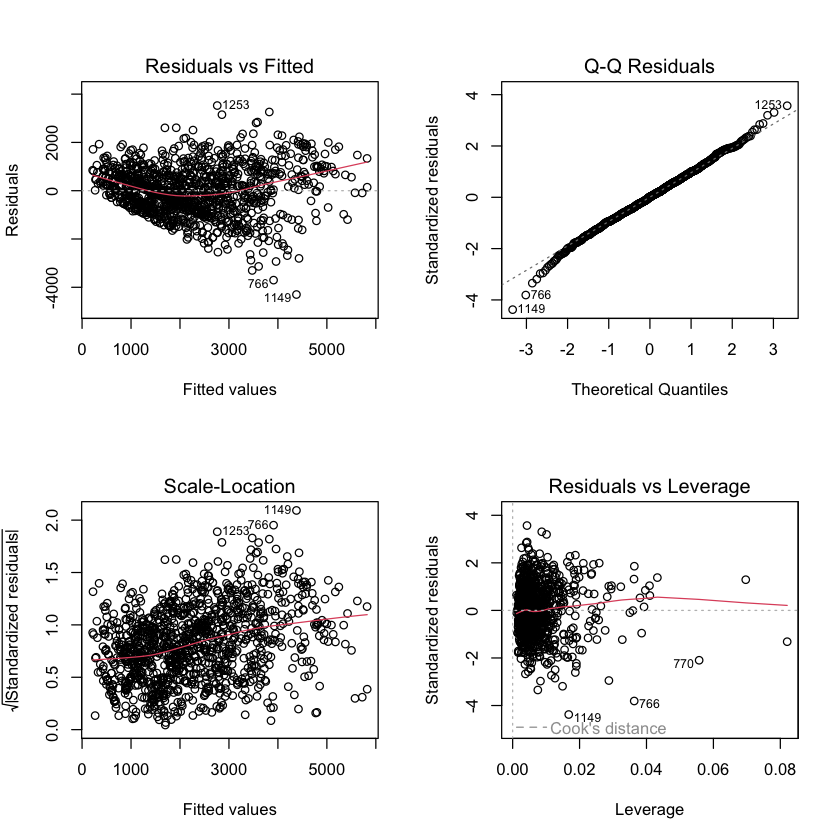

In [3]:
mlr_mod_sal = lm(sqrt(Salary) ~ Age + MP + FG + X3P + AST + DRB + BLK, data = norm.train)
summary(mlr_mod_sal)
par(mfrow = c(2, 2))
plot(mlr_mod_sal)

In [4]:
#Normality of residuals test
shapiro.test(residuals(mlr_mod_sal))


	Shapiro-Wilk normality test

data:  residuals(mlr_mod_sal)
W = 0.99699, p-value = 0.02523


Since the p-value is less than 0.05, we reject the null hypothesis and say that the residual errors are not normally distributed.

In [5]:
# Example usage for the salary prediction model
predicted_salary = predict(mlr_mod_sal, newdata = norm.test)
actual_salary = norm.test$Salary

mae_value = mae(actual_salary, predicted_salary)
print(mae_value)

[1] 7709236


#### 2. Prediction of Points


Call:
lm(formula = PTS ~ FGA + X3PA + FTA + TOV + AST, data = norm.train)

Residuals:
    Min      1Q  Median      3Q     Max 
-8.4196 -0.4222 -0.0152  0.4581  5.6737 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)    
(Intercept) -0.167248   0.048447  -3.452 0.000576 ***
FGA          1.092735   0.017965  60.826  < 2e-16 ***
X3PA         0.003642   0.023489   0.155 0.876807    
FTA          0.900725   0.036696  24.546  < 2e-16 ***
TOV         -0.282611   0.080685  -3.503 0.000478 ***
AST         -0.038329   0.026348  -1.455 0.146019    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.8637 on 1164 degrees of freedom
Multiple R-squared:  0.9736,	Adjusted R-squared:  0.9734 
F-statistic:  8570 on 5 and 1164 DF,  p-value: < 2.2e-16


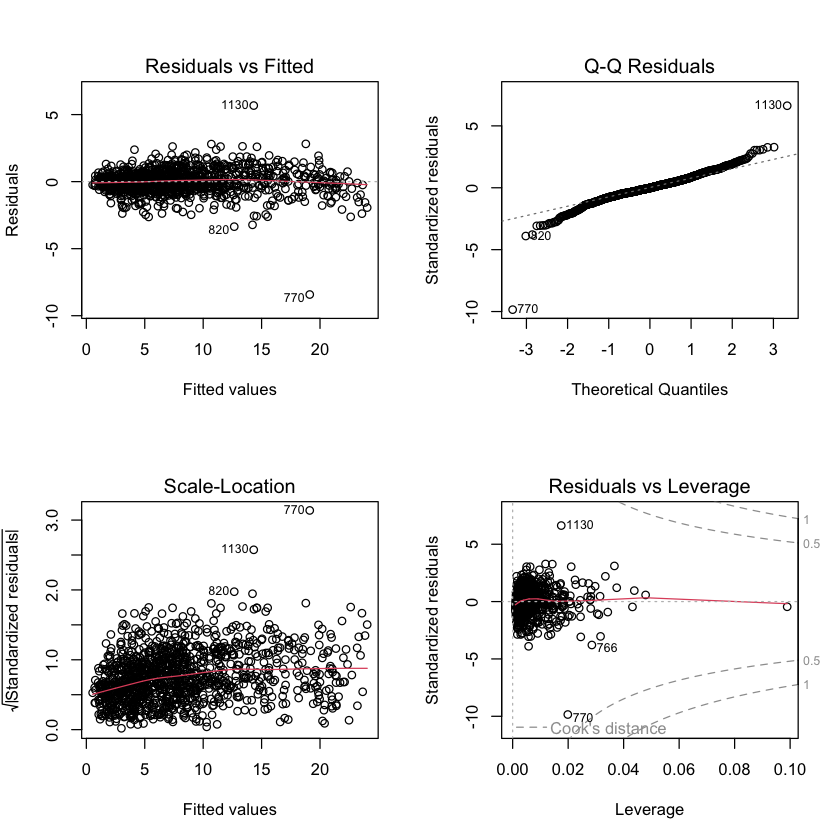

In [6]:
mlr_mod_pts = lm(PTS ~ FGA + X3PA + FTA + TOV + AST , data = norm.train)

summary(mlr_mod_pts)
par(mfrow = c(2, 2))
plot(mlr_mod_pts)

In [7]:
#Normality of residuals test
shapiro.test(residuals(mlr_mod_pts))


	Shapiro-Wilk normality test

data:  residuals(mlr_mod_pts)
W = 0.93884, p-value < 2.2e-16


Since the p-value is less than 0.05, we reject the null hypothesis and say that the residual errors are not normally distributed.

In [8]:
predicted_points = predict(mlr_mod_pts, newdata = norm.test)
actual_points = norm.test$PTS

mae_value = mae(actual_points, predicted_points)
print(mae_value)

[1] 0.6723721


## Poisson Regression

We tried to predict salary with poisson regression but the model was not able to converge. We will try to predict points per game with poisson regression.

In [9]:
pois_mod_pts = glm(as.integer(PTS) ~ FGA + X3PA + FTA + TOV + AST + offset(log(MP)), 
                         family = poisson(link = "log"), 
                         data = norm.train)

summary(pois_mod_pts)


Call:
glm(formula = as.integer(PTS) ~ FGA + X3PA + FTA + TOV + AST + 
    offset(log(MP)), family = poisson(link = "log"), data = norm.train)

Coefficients:
             Estimate Std. Error z value Pr(>|z|)    
(Intercept) -1.392967   0.024766 -56.244  < 2e-16 ***
FGA          0.053565   0.005794   9.245  < 2e-16 ***
X3PA        -0.004142   0.007851  -0.528  0.59777    
FTA          0.056398   0.011750   4.800 1.59e-06 ***
TOV         -0.015083   0.028445  -0.530  0.59594    
AST         -0.028856   0.008938  -3.229  0.00124 ** 
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for poisson family taken to be 1)

    Null deviance: 963.44  on 1169  degrees of freedom
Residual deviance: 356.44  on 1164  degrees of freedom
AIC: 4583.9

Number of Fisher Scoring iterations: 4


In [10]:
pois_mod_pts_red = glm(as.integer(PTS) ~ FGA + FTA + AST + offset(log(MP)), 
                         family = poisson(link = "log"), 
                         data = norm.train)

summary(pois_mod_pts_red)


Call:
glm(formula = as.integer(PTS) ~ FGA + FTA + AST + offset(log(MP)), 
    family = poisson(link = "log"), data = norm.train)

Coefficients:
             Estimate Std. Error z value Pr(>|z|)    
(Intercept) -1.396846   0.024109 -57.939  < 2e-16 ***
FGA          0.050809   0.003821  13.299  < 2e-16 ***
FTA          0.056855   0.009973   5.701 1.19e-08 ***
AST         -0.031603   0.007269  -4.348 1.37e-05 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for poisson family taken to be 1)

    Null deviance: 963.44  on 1169  degrees of freedom
Residual deviance: 356.93  on 1166  degrees of freedom
AIC: 4580.4

Number of Fisher Scoring iterations: 4


#### Compare the fit of models

In [12]:
anova(pois_mod_pts_red, pois_mod_pts, test = "Chisq")

,Resid. Df,Resid. Dev,Df,Deviance,Pr(>Chi)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,1166,356.9251,NA,NA,NA
2,1164,356.4372,2,0.4879478,0.7835081


$H_0$ : The reduced model is sufficient\
$H_1$ : The reduced model is not sufficient

Since the p-value is more than 0.05, we fail to reject the null hypothesis. This means that the reduced model is sufficient and we do not need to include the variable `X3PA` and `TOV` in our model.

In [13]:
predictions = predict(pois_mod_pts_red, newdata = norm.test)
mae(norm.test$PTS, predictions)

[1] 6.794469

## Generalized Additive Model (GAM)

In [14]:
library(mgcv)

Loading required package: nlme

This is mgcv 1.9-3. For overview type 'help("mgcv-package")'.



#### 1. Prediction of Salary


Family: gaussian 
Link function: identity 

Formula:
Salary ~ Age + s(MP) + FG + s(X3P) + AST + DRB + STL + BLK

Parametric coefficients:
             Estimate Std. Error t value Pr(>|t|)    
(Intercept) -19907038    1465515 -13.584  < 2e-16 ***
Age            727764      43630  16.681  < 2e-16 ***
FG            1089547     242777   4.488 7.92e-06 ***
AST           1194561     183738   6.501 1.18e-10 ***
DRB           1005418     221998   4.529 6.55e-06 ***
STL            708434     802363   0.883    0.377    
BLK            902484     620660   1.454    0.146    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Approximate significance of smooth terms:
         edf Ref.df     F  p-value    
s(MP)  6.661  7.819 5.834 1.03e-06 ***
s(X3P) 8.850  8.990 6.674  < 2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

R-sq.(adj) =  0.585   Deviance explained = 59.3%
GCV = 3.848e+13  Scale est. = 3.774e+13  n = 1170

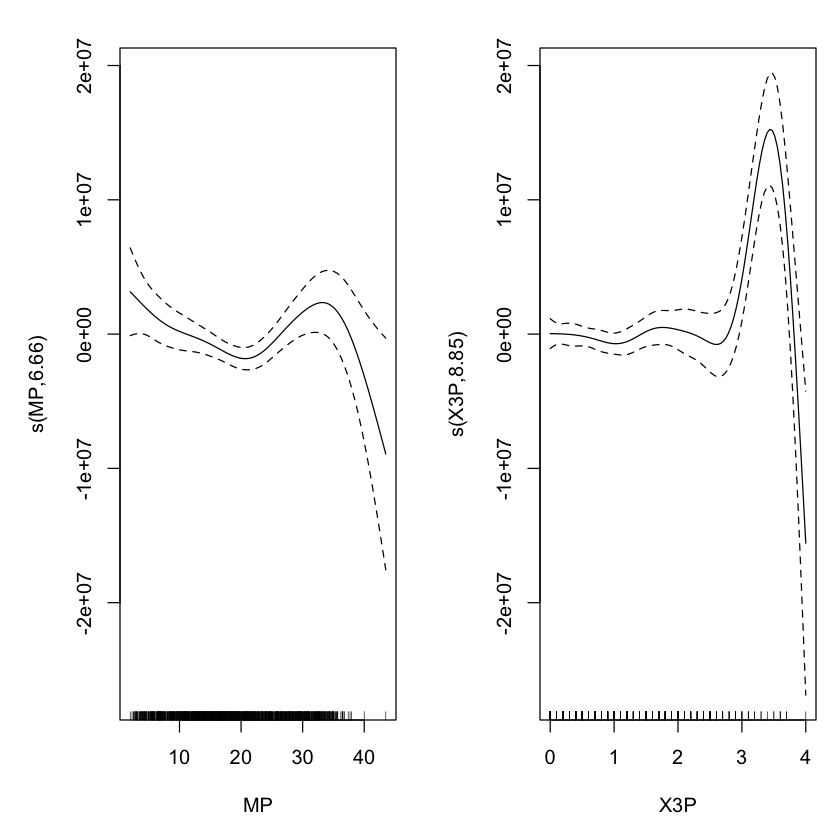

In [15]:
gam_mod_sal = gam(Salary ~ Age + s(MP) + FG + s(X3P) + AST + DRB + STL + BLK, data = norm.train)

# Summary of the model
summary(gam_mod_sal)

# Plot the smooth terms
plot.gam(gam_mod_sal, pages = 1)


Family: gaussian 
Link function: identity 

Formula:
Salary ~ Age + s(MP) + FG + s(X3P) + AST + DRB

Parametric coefficients:
             Estimate Std. Error t value Pr(>|t|)    
(Intercept) -19478242    1394552 -13.967  < 2e-16 ***
Age            726211      43588  16.661  < 2e-16 ***
FG            1096160     242242   4.525 6.66e-06 ***
AST           1205566     165795   7.271 6.56e-13 ***
DRB           1135233     201502   5.634 2.21e-08 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Approximate significance of smooth terms:
         edf Ref.df     F  p-value    
s(MP)  6.576  7.745 5.727 1.22e-06 ***
s(X3P) 8.852  8.990 6.791  < 2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

R-sq.(adj) =  0.585   Deviance explained = 59.2%
GCV = 3.845e+13  Scale est. = 3.7778e+13  n = 1170

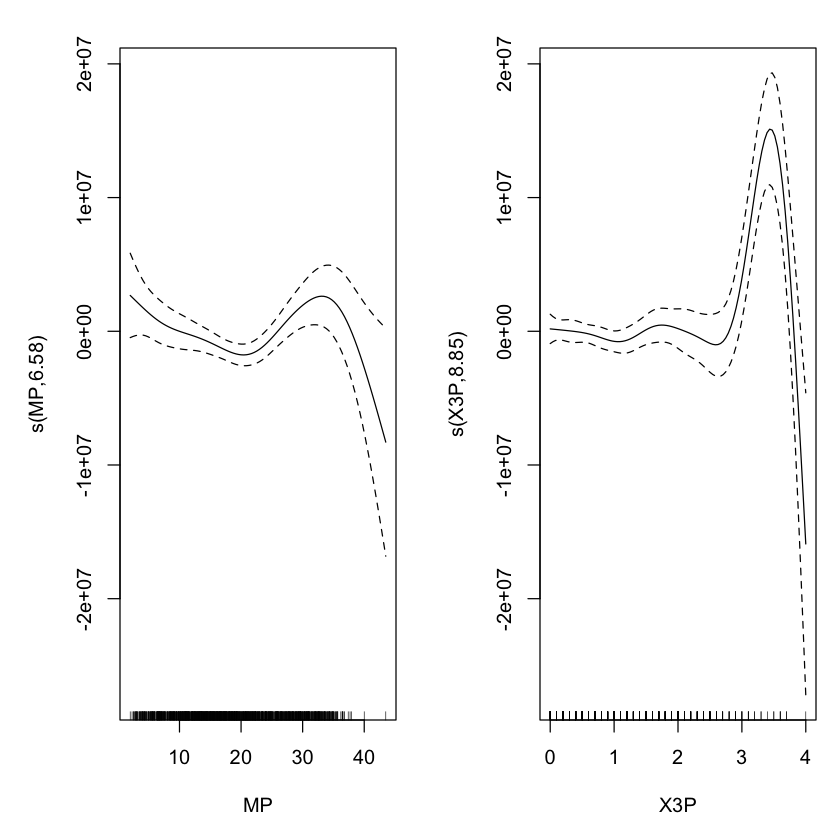

In [16]:
gam_mod_sal_red = gam(Salary ~ Age + s(MP) + FG + s(X3P) + AST + DRB , data = norm.train)

# Summary of the model
summary(gam_mod_sal_red)

# Plot the smooth terms
plot.gam(gam_mod_sal_red, pages = 1)

In [17]:
anova(gam_mod_sal_red, gam_mod_sal, test = "Chisq")

,Resid. Df,Resid. Dev,Df,Deviance,Pr(>Chi)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,1148.265,4.342886e+16,NA,NA,NA
2,1146.191,4.330621e+16,2.073684,1.22648e+14,0.2077929


$H_0$ : The reduced model is sufficient\
$H_1$ : The reduced model is not sufficient

Since the p-value is greater than 0.05, we fail to reject the null hypothesis. This means that the reduced model is sufficient and we do not need to include the variable `STL` and `BLK` in our model.

In [18]:
predicted_salary_gam = predict(gam_mod_sal_red, newdata = norm.test)
actual_salary_gam = norm.test$Salary

mae_value_gam = mae(actual_salary_gam, predicted_salary_gam)
print(mae_value_gam)

[1] 4836939


#### 2. Prediction of Points


Family: gaussian 
Link function: identity 

Formula:
PTS ~ FGA + s(X3PA) + FTA + s(TOV) + s(AST)

Parametric coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept) -0.31440    0.10090  -3.116  0.00188 ** 
FGA          1.06678    0.01801  59.219  < 2e-16 ***
FTA          0.88385    0.03640  24.282  < 2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Approximate significance of smooth terms:
          edf Ref.df     F p-value    
s(X3PA) 4.337  5.314 8.830 < 2e-16 ***
s(TOV)  8.753  8.971 7.205 < 2e-16 ***
s(AST)  5.526  6.639 3.775 0.00068 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

R-sq.(adj) =  0.976   Deviance explained = 97.6%
GCV = 0.68762  Scale est. = 0.67492   n = 1170

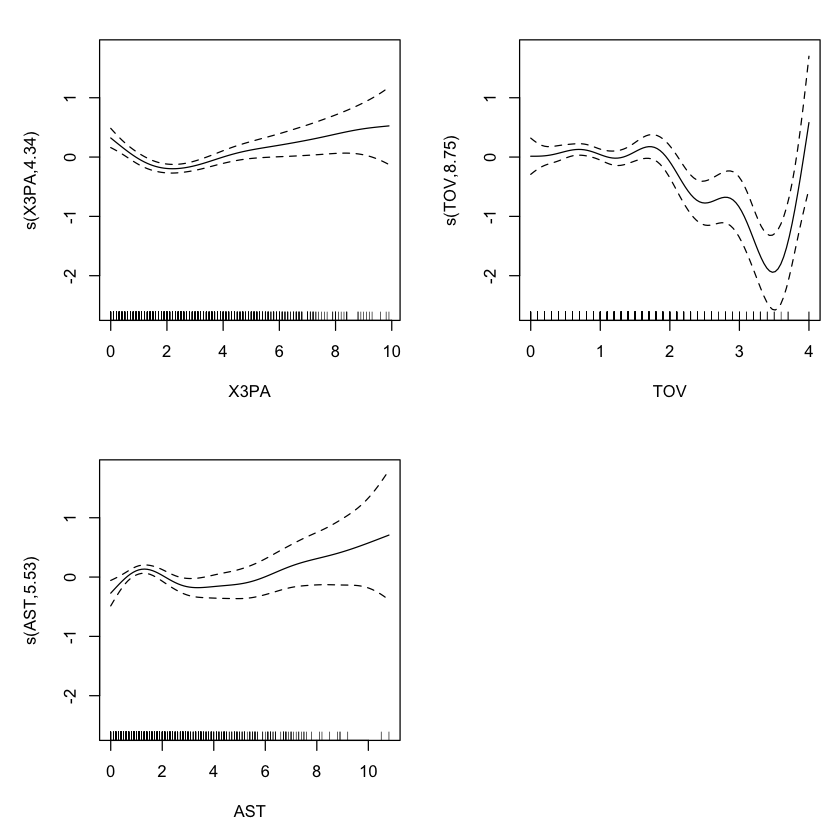

In [19]:
gam_mod_pts = gam(PTS ~ FGA + s(X3PA) + FTA + s(TOV) + s(AST), data = norm.train)

# Summary of the model
summary(gam_mod_pts)

# Plot the smooth terms
plot.gam(gam_mod_pts, pages = 1)

In [20]:
predicted_points_gam = predict(gam_mod_pts, newdata = norm.test)
actual_points_gam = norm.test$PTS

mae_value_gam_pts = mae(actual_points_gam, predicted_points_gam)
print(mae_value_gam_pts)

[1] 0.6301842


## Results and Conclusion

#### 1. Hypothesis Testing 

#### 2. Multiple Linear Regression

**Salary Prediction**

The regression output showed that the model explains about 57% of the variation in the square root of salaries, with an adjusted R-squared of 0.568, indicating a moderately strong fit. From the regression results, Age, field goals, 3-point field goals, assists, defensive rebounds, and blocks all had p-values below 0.05, were significant features. Interestingly, minutes played did not show statistical significance, indicating it may not independently influence salary after accounting for other variables.

Model diagnostics were examined using residual plots. The residuals vs. fitted plot showed no major pattern but the red line was slightly deviated from y = 0, supporting the assumption of linearity. The Q-Q plot indicated mild deviations from normality in the tails, which was supported by the Shapiro-Wilk test. The scale-location plot showed minor heteroscedasticity, and the residuals vs. leverage plot did not reveal any data points with high influence (based on Cook’s distance), indicating a stable model.

The MAE (7709236) suggests that while the model captures key trends, there is room for improvement in precision. Overall, the model highlights that scoring, playmaking, defensive contributions, and age are key factors influencing NBA player salaries.

**Points Prediction**

The regression output showed that the model explains about 97.36% of the variation in points scored, with an adjusted R-squared of 0.9734, indicating an excellent fit. Field goal attempts (FGA), free throw attempts (FTA), and turnovers (TOV) were statistically significant predictors of points (p < 0.001), while 3-point attempts (X3PA) and assists (AST) were not significant.

Model diagnostics indicated good linearity, with residuals showing a random scatter and the red smoothing line close to zero. The Q-Q plot revealed noticeable departures from normality, which is supported by the Shapiro-Wilk test (p < 2.2e-16). The scale-location and leverage plots suggest homoscedasticity and no influential outliers (Cook’s distance < 1).

The MAE (0.6724) indicates highly accurate predictions on test data. Overall, the model effectively captures the key contributors to points scored, especially emphasizing shot attempts and free throws.

#### 3. Poisson Regression

**Salary Prediction**
The Poisson regression model was not performing well and did not converge, indicating that the salary may not be suitable for this type of model as a target from initial analysis.

**Points Prediction**

The Poisson regression model was developed to predict points scored (PTS) using variables like field goal attempts (FGA), free throw attempts (FTA), assists (AST), and an exposure term log(MP) to adjust for playing time. In the full model, FGA, FTA, and AST were significant, while 3-point attempts (X3PA) and turnovers (TOV) were not. A reduced model excluding the non-significant variables yielded similar residual deviance and a slightly improved AIC (4580.4 vs. 4583.9).

Model comparison via chi-square test showed no significant difference between the full and reduced models (p = 0.78), justifying the simpler model. All retained predictors remained significant in the reduced model (p < 0.001). The model fits well with a substantial reduction from the null deviance (963.4 to 356.9).

However, the MAE for this model (6.79) is higher than that of the previous linear regression model (0.67), indicating reduced predictive accuracy. While the Poisson model accounts for count-based distribution and exposure time, it may be less precise for continuous or high-resolution point prediction tasks.

#### 4. Generalized Additive Model (GAM) 
**Salary Prediction**

The model was used to predict NBA player salaries using both linear terms and smooth functions for non-linear relationships (Minutes Played and 3-Point Shots). In the full model, Age, FG, AST, and DRB were significant predictors, while Steals and Blocks were not. Smooth terms for MP and X3P were both highly significant, suggesting nonlinear effects.

A reduced GAM model excluding non-significant predictors (STL and BLK) showed nearly identical performance (Adjusted $R^2$ = 0.585, Deviance Explained = 59.2%). The ANOVA comparison confirmed that the reduced model was not significantly worse (p = 0.21).

The final GAM outperformed the linear model in predictive accuracy, yielding an MAE of 4836939. This suggests that incorporating nonlinear effects improves salary prediction performance while maintaining interpretability.


**Points Prediction**

The model for predicting points (PTS) used both linear terms (FGA, FTA) and nonlinear smooth functions for X3-point attempts, turnovers, and assists. All predictors, including the smooth terms, were statistically significant (p < 0.001), indicating that both shooting volume and playmaking behaviors have nonlinear effects on points scored.

The model achieved an adjusted R-squared of 0.976 and explained 97.6% of the deviance, indicating an excellent fit. The MAE was 0.63, slightly better than the linear regression model. Overall, this model effectively captures complex relationships in scoring patterns, improving both interpretability and prediction accuracy.

#### Comparison
##### Salary

| Model Type         | Adjusted $R^2$ / Deviance Explained | MAE       | Significant Predictors           |
|---------------------|----------------------------------|-----------|-----------------------------------|
| Linear Regression   | 0.568                           | 7,709,236 | Age, FG, 3P, AST, DRB, BLK       |
| GAM (Reduced)       | 0.585                           | 4,836,939 | Age, FG, AST, DRB, s(MP), s(X3P) |

##### Points

| Model Type         | Adjusted $R^2$ / Deviance Explained | MAE   | Significant Predictors                  |
|---------------------|----------------------------------|-------|------------------------------------------|
| Linear Regression   | 0.9734                           | 0.672 | FGA, FTA, TOV                           |
| Poisson GLM         | Deviance Explained: ~63%         | 6.79  | FGA, FTA, AST, offset(log(MP))           |
| GAM                 | 0.976                            | 0.630 | FGA, FTA, s(X3PA), s(TOV), s(AST)        |
